In [12]:
import math

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
import torch
from kan import KAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import classification_report, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from datetime import datetime

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EPOCHS = 2
TRIALS = 10

In [3]:
data = pd.read_csv("DATA/income (IC)/Preprocessed/data_processed.csv")

y = data["target_label"].values
data.drop("target_label", axis=1, inplace=True)
X = data.values.astype(np.float32)

if y.dtype == "object":
    label_encoder = LabelEncoder()
    y = torch.tensor(label_encoder.fit_transform(y)).reshape(-1, 1).float()
else:
    y = torch.tensor(y).reshape(-1, 1).float().to(device)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train, y_train, stratify=y_train, test_size=0.1, random_state=42
)


pca = PCA(n_components=0.999)
X_train = torch.tensor(pca.fit_transform(X_train)).to(device)
X_valid = torch.tensor(pca.transform(X_valid)).to(device)
X_test = torch.tensor(pca.transform(X_test)).to(device)

input_shape = X_train.shape[1]
output_shape = y_train.shape[1]

print("Reduce number of features from %d to %d." % (data.shape[1], input_shape))

dataset = {
    "train_input": X_train,
    "train_label": y_train,
    "test_input": X_valid,
    "test_label": y_valid,
}

Reduce number of features from 108 to 2.


In [5]:
def objective(trial):
    depth = trial.suggest_int("depth", 1, 3)
    grid = trial.suggest_int("grid", 1, 3)
    k = trial.suggest_int("k", 1, 4)

    width = [trial.suggest_int(f"neurons_layer_{i}", 1, 10) for i in range(depth)]
    width = [input_shape] + width + [output_shape]

    model = KAN(width=width, grid=grid, k=k, device=device).speed()

    # Train the model
    history = model.fit(dataset, steps=EPOCHS)

    # Evaluate the model
    y_score = model(X_valid).cpu()
    y_pred = (y_score > 0.5).int()

    return f1_score(y_valid, y_pred, average="macro")

In [6]:
# Step 3: Create a Study and Optimize
study = optuna.create_study(direction="maximize")  # Change to "minimize" if needed
study.optimize(objective, n_trials=TRIALS)  # Adjust the number of trials as needed

[I 2024-12-29 09:13:05,599] A new study created in memory with name: no-name-8ff2b4ba-6f9d-47d2-b3a2-005901194c57


checkpoint directory created: ./model
saving model version 0.0


| train_loss: 9.26e+00 | test_loss: 8.79e+00 | reg: 0.00e+00 | : 100%|█| 2/2 [00:18<00:00,  9.20s/it
[I 2024-12-29 09:13:24,105] Trial 0 finished with value: 0.37159156478012534 and parameters: {'depth': 1, 'grid': 3, 'k': 4, 'neurons_layer_0': 9}. Best is trial 0 with value: 0.37159156478012534.


checkpoint directory created: ./model
saving model version 0.0


| train_loss: 3.18e+01 | test_loss: 3.78e+01 | reg: 0.00e+00 | : 100%|█| 2/2 [00:15<00:00,  7.93s/it
[I 2024-12-29 09:13:40,015] Trial 1 finished with value: 0.49308111468463156 and parameters: {'depth': 1, 'grid': 2, 'k': 4, 'neurons_layer_0': 9}. Best is trial 1 with value: 0.49308111468463156.


...

| train_loss: 1.66e+01 | test_loss: 1.11e+01 | reg: 0.00e+00 | : 100%|█| 2/2 [00:09<00:00,  4.76s/it
[I 2024-12-29 09:14:37,237] Trial 7 finished with value: 0.48883851105049936 and parameters: {'depth': 1, 'grid': 1, 'k': 3, 'neurons_layer_0': 10}. Best is trial 5 with value: 0.5357429747688962.


checkpoint directory created: ./model
saving model version 0.0


| train_loss: 5.00e-01 | test_loss: 4.99e-01 | reg: 0.00e+00 | : 100%|█| 2/2 [00:03<00:00,  1.54s/it
[I 2024-12-29 09:14:40,353] Trial 8 finished with value: 0.3333333333333333 and parameters: {'depth': 2, 'grid': 1, 'k': 1, 'neurons_layer_0': 9, 'neurons_layer_1': 1}. Best is trial 5 with value: 0.5357429747688962.


checkpoint directory created: ./model
saving model version 0.0


| train_loss: 6.81e-01 | test_loss: 6.81e-01 | reg: 0.00e+00 | : 100%|█| 2/2 [00:00<00:00,  4.19it/s
[I 2024-12-29 09:14:40,858] Trial 9 finished with value: 0.3333333333333333 and parameters: {'depth': 1, 'grid': 2, 'k': 2, 'neurons_layer_0': 2}. Best is trial 5 with value: 0.5357429747688962.


In [8]:
best_params = study.best_params
print(best_params)
depth = best_params["depth"]
grid = best_params["grid"]
k = best_params["k"]
width = [best_params[f"neurons_layer_{i}"] for i in range(depth)]
width = [input_shape] + width + [output_shape]  # Add input and output shapes

model = KAN(width=width, grid=grid, k=k, device=device)

# Train the model
history = model.fit(dataset, steps=EPOCHS)

y_score = model(X_test).cpu()
y_pred = (y_score > 0.5).int()

{'depth': 3, 'grid': 2, 'k': 1, 'neurons_layer_0': 7, 'neurons_layer_1': 6, 'neurons_layer_2': 6}
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 4.87e-01 | test_loss: 4.89e-01 | reg: 2.88e+01 | : 100%|█| 2/2 [00:11<00:00,  5.92s/it

saving model version 0.1


In [9]:
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))
print("ROC-AUC: %.4f" % roc_auc_score(y_test, y_pred))

              precision    recall  f1-score   support

          No       0.56      0.48      0.52      4944
         Yes       0.54      0.62      0.58      4944

    accuracy                           0.55      9888
   macro avg       0.55      0.55      0.55      9888
weighted avg       0.55      0.55      0.55      9888

ROC-AUC: 0.5509


In [13]:
results = study.trials_dataframe()
vars = results[["params_depth", "params_grid", "params_k"]]
values = results["value"].round(2)
results.to_csv('results-%s.csv' % datetime.datetime.now())

AttributeError: type object 'datetime.datetime' has no attribute 'datetime'

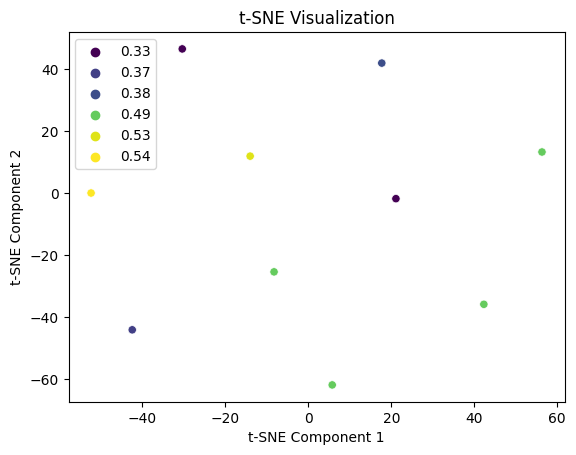

In [11]:
# Perform t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=len(values)-1)
tsne_results = tsne.fit_transform(vars)

# Create a DataFrame for the t-SNE results
tsne_df = pd.DataFrame(tsne_results, columns=["TSNE1", "TSNE2"])
tsne_df["value"] = values

# Plotting the t-SNE results
# plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=tsne_df, x="TSNE1", y="TSNE2", hue="value", palette="viridis", legend="full"
)
plt.title("t-SNE Visualization")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend()